## 03_Validation_DCA_SHAP
### Validation, Calibration, DCA, SHAP Interpretation

In [1]:
# 导入包
import warnings
warnings.filterwarnings("ignore")

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.metrics import (
    roc_auc_score, roc_curve, precision_recall_curve,
    average_precision_score, confusion_matrix, f1_score,
    brier_score_loss
)

from sklearn.calibration import calibration_curve
from sklearn.utils import resample

import shap

#plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False
sns.set_style("whitegrid")

In [4]:
# 文件夹
os.makedirs("figures", exist_ok=True)
os.makedirs("results", exist_ok=True)

# 加载模型与数据
best_models = joblib.load("/Users/hry/Downloads/code&results/results/results_balanced/balanced_2/best_models.pkl")
predictions = joblib.load("/Users/hry/Downloads/code&results/results/results_balanced/balanced_2/predictions.pkl")
data_split = joblib.load("/Users/hry/Downloads/code&results/results/results_balanced/balanced_2/data_split.pkl")
X_test = data_split["X_test"]
y_test = data_split["y_test"]

ModuleNotFoundError: No module named 'numpy._core'

Bootstrap ROC & PR
随机抽样 1000 次
输出均值 ± 标准差

In [3]:
# Bootstrap ROC & PR
n_bootstrap = 1000
rng = np.random.RandomState(42)

roc_results = {}
pr_results = {}

for name in best_models.keys():
    y_prob = predictions[name]["y_prob"]
    aucs, aps = [], []
    for i in range(n_bootstrap):
        idx = rng.choice(len(y_test), len(y_test), replace=True)
        if len(np.unique(y_test.iloc[idx]))<2:
            continue
        aucs.append(roc_auc_score(y_test.iloc[idx], y_prob[idx]))
        aps.append(average_precision_score(y_test.iloc[idx], y_prob[idx]))
    roc_results[name] = (np.mean(aucs), np.std(aucs))
    pr_results[name] = (np.mean(aps), np.std(aps))


阈值优化（临床决策阈值分析）
Youden Index
F1 最大值
输出 threshold_analysis.csv

In [4]:
# Threshold optimization (F1 & Youden)
threshold_analysis = []

for name in best_models.keys():
    y_prob = predictions[name]["y_prob"]
    fpr, tpr, roc_thresh = roc_curve(y_test, y_prob)
    youden_idx = np.argmax(tpr - fpr)
    youden_thresh = roc_thresh[youden_idx]
    
    precision, recall, pr_thresh = precision_recall_curve(y_test, y_prob)
    f1_scores = 2*precision*recall/(precision+recall+1e-8)
    f1_idx = np.argmax(f1_scores)
    f1_thresh = pr_thresh[f1_idx] if f1_idx<len(pr_thresh) else 0.5
    
    threshold_analysis.append([name, youden_thresh, f1_thresh])

threshold_df = pd.DataFrame(
    threshold_analysis, columns=["Model","Youden_Threshold","F1_Threshold"]
)
threshold_df.to_csv("results/threshold_analysis.csv", index=False)

Calibration Curve + Brier Score
10 个 bin
输出 Brier_Score.csv

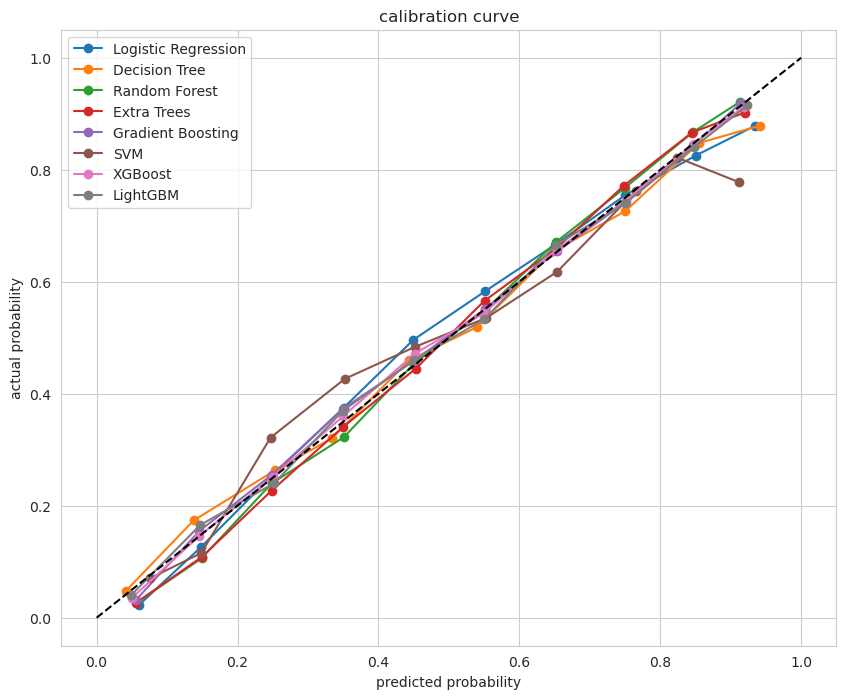

In [5]:
# Calibration Curve & Brier Score
plt.figure(figsize=(10,8))
brier_scores = []

for name in best_models.keys():
    y_prob = predictions[name]["y_prob"]
    prob_true, prob_pred = calibration_curve(y_test, y_prob, n_bins=10)
    plt.plot(prob_pred, prob_true, marker='o', label=name)
    bs = brier_score_loss(y_test, y_prob)
    brier_scores.append((name, bs))

plt.plot([0,1],[0,1],"k--")
plt.xlabel("predicted probability")
plt.ylabel("actual probability")
plt.title("calibration curve")      #校准曲线
plt.legend()
plt.savefig("figures/Calibration_Curve.png", dpi=300)
plt.show()

brier_df = pd.DataFrame(brier_scores, columns=["Model","Brier_Score"]).sort_values("Brier_Score")
brier_df.to_csv("results/Brier_Score.csv", index=False)

DCA
使用净收益公式
阈值 0.01–0.99

In [2]:
# Decision Curve Analysis (DCA)
def net_benefit(y_true, y_prob, thresholds):
    N = len(y_true)
    nb = []
    for pt in thresholds:
        y_pred = (y_prob >= pt).astype(int)
        TP = ((y_pred==1)&(y_true==1)).sum()
        FP = ((y_pred==1)&(y_true==0)).sum()
        nb.append(TP/N - FP/N * (pt/(1-pt)))
    return nb

thresholds = np.arange(0.01,0.99,0.01)
prevalence = np.mean(y_test)
# Treat None
nb_none = np.zeros_like(thresholds)
# Treat All
nb_all = prevalence - (1 - prevalence) * thresholds / (1 - thresholds)

plt.figure(figsize=(10,8))

plt.plot(thresholds, nb_none, 'k--', linewidth=2, label='Treat None')
plt.plot(thresholds, nb_all, color='gray', linewidth=2, label='Treat All')

for name in best_models.keys():
    y_prob = predictions[name]["y_prob"]
    nb = net_benefit(y_test, y_prob, thresholds)
    plt.plot(thresholds, nb, label=name)

plt.xlabel("threshold")     # 阈值
plt.ylabel("net benefit")     #净收益
plt.title("Decision Curve Analysis (DCA)")
plt.legend()
plt.savefig("figures/DCA.png", dpi=300)
plt.show()

NameError: name 'y_test' is not defined

SHAP解释
仅对最佳模型
随机抽样 3000 样本
输出 Summary + Bar 图

最佳模型: XGBoost


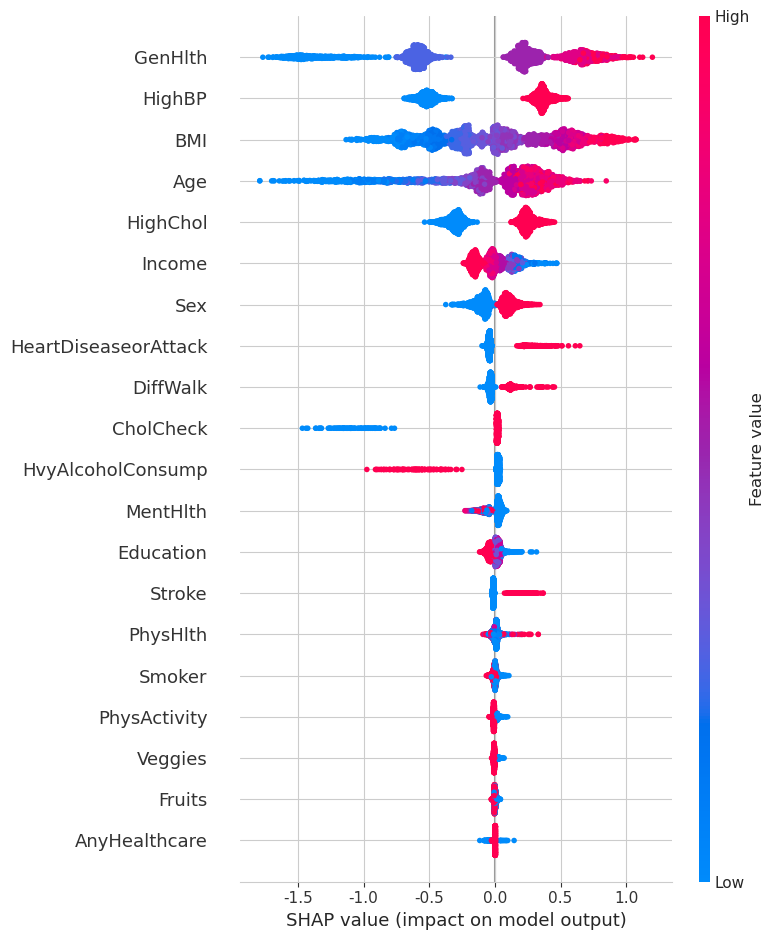

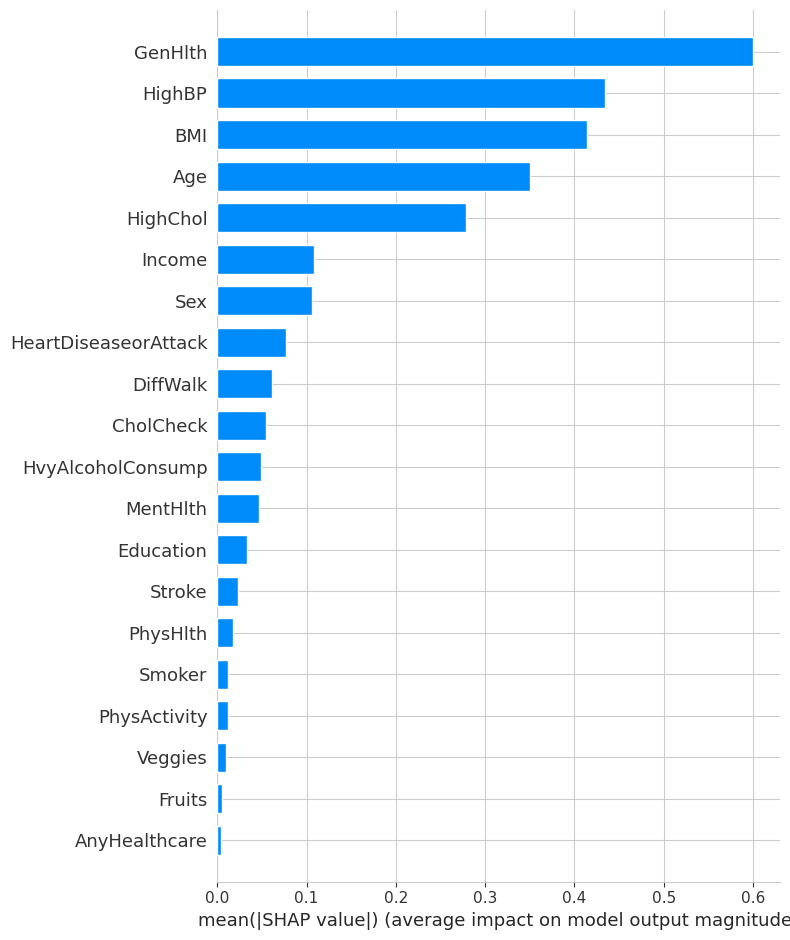


Validation, Calibration, DCA, SHAP完成。


In [10]:
# SHAP Interpretation (仅最佳模型)
best_model_name = max(roc_results, key=lambda k: roc_results[k][0])
print("最佳模型:", best_model_name)

best_model = best_models[best_model_name]

# 只抽样3000个样本减少内存
sample_idx = np.random.choice(len(X_test), 3000, replace=False)
X_shap = X_test.iloc[sample_idx]

if hasattr(best_model, "predict_proba"):
    explainer = shap.TreeExplainer(best_model)
    shap_values = explainer.shap_values(X_shap)
    shap.summary_plot(shap_values, X_shap, show=False)
    plt.savefig("figures/SHAP_Summary.png", dpi=300)
    plt.show()
    plt.close()
    shap.summary_plot(shap_values, X_shap, plot_type="bar", show=False)
    plt.savefig("figures/SHAP_Bar.png", dpi=300)
    plt.show()
    plt.close()
else:
    print("最佳模型不支持SHAP解释")

print("\nValidation, Calibration, DCA, SHAP完成。")

In [8]:
# Bootstrap ΔAUC
from itertools import combinations

baseline_name = "Logistic Regression"
baseline_prob = predictions[baseline_name]["y_prob"]

auc_diff_results = []

n_bootstrap = 1000
rng = np.random.RandomState(42)

for name in best_models.keys():
    if name == baseline_name:
        continue
    model_prob = predictions[name]["y_prob"]
    delta_auc = []
    for i in range(n_bootstrap):
        idx = rng.choice(len(y_test), len(y_test), replace=True)
        if len(np.unique(y_test.iloc[idx]))<2:
            continue
        auc1 = roc_auc_score(y_test.iloc[idx], model_prob[idx])
        auc0 = roc_auc_score(y_test.iloc[idx], baseline_prob[idx])
        delta_auc.append(auc1 - auc0)
    mean_diff = np.mean(delta_auc)
    ci_lower = np.percentile(delta_auc, 2.5)
    ci_upper = np.percentile(delta_auc, 97.5)
    p_value = (np.sum(np.array(delta_auc)<=0)+1)/(len(delta_auc)+1)
    auc_diff_results.append([name, mean_diff, ci_lower, ci_upper, p_value])

auc_diff_df = pd.DataFrame(
    auc_diff_results,
    columns=["Model vs LR","ΔAUC","CI_lower","CI_upper","P_value"]
)
auc_diff_df.to_csv("results/Bootstrap_Delta_AUC.csv", index=False)
print("\nBootstrap ΔAUC 已保存")


Bootstrap ΔAUC 已保存


In [9]:
# NRI / IDI
def calc_nri_idi(y_true, prob_new, prob_ref, threshold=0.5):
    """
    计算NRI和IDI
    """
    y_true = np.array(y_true)
    prob_new = np.array(prob_new)
    prob_ref = np.array(prob_ref)
    
    # 二分类风险重分类
    reclass_up = (prob_new >= threshold) & (prob_ref < threshold)
    reclass_down = (prob_new < threshold) & (prob_ref >= threshold)
    
    # NRI
    event_idx = y_true==1
    non_event_idx = y_true==0
    nri_event = np.mean(reclass_up[event_idx]) - np.mean(reclass_down[event_idx])
    nri_nonevent = np.mean(reclass_down[non_event_idx]) - np.mean(reclass_up[non_event_idx])
    nri = nri_event + nri_nonevent
    
    # IDI
    idi = (np.mean(prob_new[event_idx])-np.mean(prob_ref[event_idx])) - \
          (np.mean(prob_new[non_event_idx])-np.mean(prob_ref[non_event_idx]))
    
    return nri, idi

nri_idi_results = []

for name in best_models.keys():
    if name == baseline_name:
        continue
    prob_new = predictions[name]["y_prob"]
    nri, idi = calc_nri_idi(y_test, prob_new, baseline_prob, threshold=0.5)
    nri_idi_results.append([name, nri, idi])

nri_idi_df = pd.DataFrame(
    nri_idi_results,
    columns=["Model vs LR","NRI","IDI"]
)
nri_idi_df.to_csv("results/NRI_IDI.csv", index=False)
print("NRI/IDI 已保存")

NRI/IDI 已保存
